In [12]:
import numpy as np
import torch
from flonacomldft.gaussian_utils import MoG
import matplotlib.pyplot as plt

In [13]:
## Constants
from ase.units import kB
T = 300
beta = 1 / (kB * T)

## Target model - Gaussian mixture

In [14]:
sep = 2.
means = [torch.tensor([-sep, 0]), torch.tensor([sep, 0])]
covars = [2e-1 * torch.eye(2),  2e-1 * torch.eye(2)]

target = MoG(means, covars, weights=[0.2, 0.8])

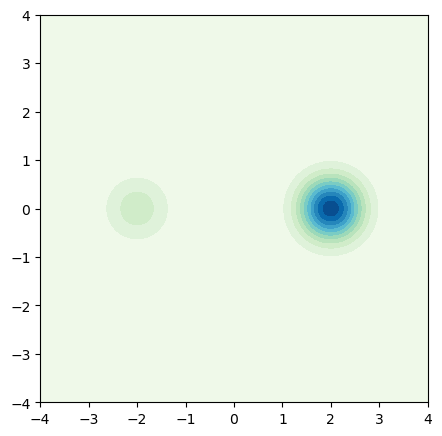

In [15]:
lims = {'x_min':-2 * sep, 'x_max':2 * sep, 'y_min':-2 * sep, 'y_max':2 * sep}
device = 'cpu'

## TODO: add to gaussian utils

def set_plot(ax, n_points=1000, target_log_prob=target.log_prob, prop_log_prob=None, lims=lims):
    
    x_range = torch.linspace(lims['x_min'], lims['x_max'], n_points, device=device)

    if lims['y_min'] is None:
        y_range = x_range.clone()
    else:
        y_range = torch.linspace(lims['y_min'], lims['y_max'], n_points, device=device)

    grid = torch.meshgrid(x_range, y_range)
    xys = torch.stack(grid).reshape(2, n_points ** 2).T.to(device)

    Us_target = target_log_prob(xys).reshape(n_points, n_points).T.detach().cpu().numpy()

    if ax is None:
        plt.figure()
    else:
        plt.sca(ax)
    #plt.axis('off')

    plt.contourf(x_range, y_range, np.exp(Us_target)
    # np.log( - Us_target + Us_target.max() + 1)
    , 10, cmap='GnBu')
    ax.set_aspect('equal')

    if prop_log_prob is not None:
        Us_prop = prop_log_prob(xys).reshape(n_points, n_points).T.detach().cpu().numpy()

        plt.contour(x_range, y_range, np.exp(Us_prop), 10, colors='k', linestyles=':', alpha=0.5)


plt.figure(figsize=(5,7))
ax = plt.subplot(1,1,1)
set_plot(ax)

## Create dataset

In [16]:
n_samples = 10000

target_samples = target.sample(n_samples)
target_us = target.U(target_samples)
id_mode = torch.zeros(n_samples)

dataset = torch.cat([target_samples.T, target_us.reshape(1, -1), id_mode.reshape(1, -1)]).T

train = dataset[:int(n_samples*0.8)]
test = dataset[int(n_samples*0.8):]

/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/torch/distributions/distribution.py:159: UserWarning: sample_n will be deprecated. Use .sample((n,)) instead
  warnings.warn('sample_n will be deprecated. Use .sample((n,)) instead', UserWarning)


## Energy setup

In [17]:
target_energy = lambda x: target.U(x) / beta
mlp_dic = {'model': target_energy}

## Create flow

In [18]:
from flonacomldft.models.real_nvp import RealNVP_MLP
from flonacomldft.train_flow_from_data import train_flow

In [8]:
n_blocks = 4
hidden_dim = 64
hidden_depth = 4

model = RealNVP_MLP(2,
                    n_blocks=n_blocks,
                    block_depth=1,
                    init_weight_scale=1e-3,
                    base_cov=None,
                    hidden_dim=hidden_dim,
                    hidden_depth=hidden_depth,
                    device=device,
                    )

## Train flow

In [9]:
flow_dic = train_flow(
    model,
    train,
    test,
    dim=2,
    n_iter=50,
    lr=1e-3,
    use_scheduler=False,
    step_schedule=int(100000/10),
    save_splits=10,
    grad_clip=1e4,
    with_tqdm=False,
    compute_part_ratio=True,
    energy_type='mlp',
    mlp_model=target.U,
    n_prop=1000,
)

t=0.0e+00 	 loss: 4.03	Gd: 2e+00	lr: 1.00e-03
t=5.0e+00 	 loss: 4.00	Gd: 2e+00	lr: 1.00e-03
t=1.0e+01 	 loss: 3.96	Gd: 2e+00	lr: 1.00e-03
t=1.5e+01 	 loss: 3.91	Gd: 2e+00	lr: 1.00e-03
t=2.0e+01 	 loss: 3.83	Gd: 2e+00	lr: 1.00e-03
t=2.5e+01 	 loss: 3.71	Gd: 2e+00	lr: 1.00e-03
t=3.0e+01 	 loss: 3.55	Gd: 1e+00	lr: 1.00e-03
t=3.5e+01 	 loss: 3.35	Gd: 1e+00	lr: 1.00e-03
t=4.0e+01 	 loss: 3.11	Gd: 1e+00	lr: 1.00e-03
t=4.5e+01 	 loss: 2.88	Gd: 9e-01	lr: 1.00e-03


## Plot target model and pretrained flow model

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


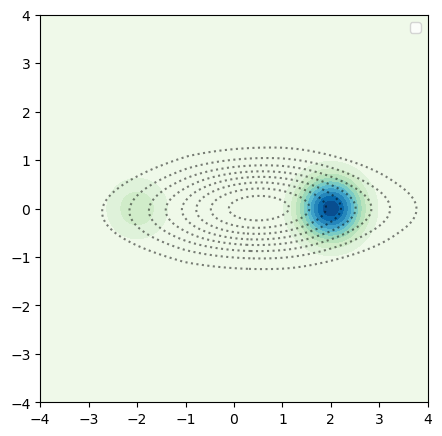

In [10]:
fig, ax = plt.subplots(1,1, figsize=(5,7))
flowlogprob = lambda x: -flow_dic['model'].nll(x)
set_plot(ax, n_points=1000, target_log_prob=target.log_prob, prop_log_prob=flowlogprob, lims=lims)

plt.legend()

## Participation ratio

In [23]:
torch.stack(flow_dic['part_ratios'])

tensor([0.0034, 0.0029, 0.0021, 0.0027, 0.0019, 0.0020, 0.0046, 0.0029, 0.0026,
        0.0022, 0.0011, 0.0020, 0.0033, 0.0032, 0.0022, 0.0019, 0.0024, 0.0014,
        0.0013, 0.0025, 0.0020, 0.0026, 0.0037, 0.0019, 0.0028, 0.0011, 0.0023,
        0.0021, 0.0028, 0.0032, 0.0041, 0.0035, 0.0020, 0.0030, 0.0019, 0.0036,
        0.0075, 0.0062, 0.0026, 0.0035, 0.0036, 0.0091, 0.0032, 0.0060, 0.0079,
        0.0091, 0.0032, 0.0064, 0.0050, 0.0089], grad_fn=<StackBackward0>)

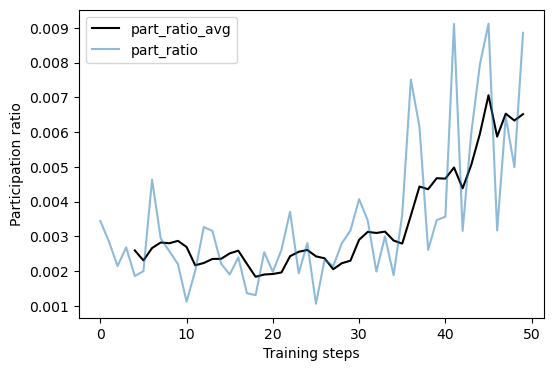

In [32]:
from flonacomldft.utils.plots import set_plot_iteration

fig, ax = plt.subplots(1,1, figsize=(6,4))
set_plot_iteration(torch.stack(flow_dic['part_ratios']).detach(), avg=True, window_size=5, axis=1, ax=ax, label='part_ratio')
ax.set_xlabel('Training steps')
ax.set_ylabel('Participation ratio')
ax.legend()

## Adaptive sampling

In [11]:
from flonacomldft.full_adaptive_sampling import adaptive_sampling

In [12]:
flow_hyperparams = {'n_iter': 100,
    'lr': 1e-3,
    'use_scheduler': False,
    'step_schedule': 100,
    'save_splits': 10,
    'grad_clip': 1e4}


In [13]:
# MCMC Params
n_runs = 10
n_chains = 25
n_steps = 50

# Init chains
init_samples = target.sample(n_chains)
init_us = target.U(init_samples)
init_id_mode = torch.zeros(n_chains)

init_mcmc = torch.cat([init_samples.T, init_us.reshape(1, -1), init_id_mode.reshape(1, -1)]).T

/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/torch/distributions/distribution.py:159: UserWarning: sample_n will be deprecated. Use .sample((n,)) instead
  warnings.warn('sample_n will be deprecated. Use .sample((n,)) instead', UserWarning)


In [14]:
_ = adaptive_sampling(train, 
                         test,
                         init_mcmc, 
                         dim=2,
                         dict_flows_init=[flow_dic],
                         dict_mlps_init=[mlp_dic],
                         mixture=False,
                         flow_hyperparams=[flow_hyperparams],
                         n_runs=n_runs,
                         n_chains=n_chains,
                         n_steps=n_steps,
                        )

step: 0 	 acc: 1.00
step: 5 	 acc: 0.40
step: 10 	 acc: 0.28
step: 15 	 acc: 0.24
step: 20 	 acc: 0.28
step: 25 	 acc: 0.40
step: 30 	 acc: 0.16
step: 35 	 acc: 0.32
step: 40 	 acc: 0.20
step: 45 	 acc: 0.32
t=0.0e+00 	 loss: 2.75	Gd: 6e-01	lr: 1.00e-03
t=1.0e+01 	 loss: 2.59	Gd: 2e-01	lr: 1.00e-03
t=2.0e+01 	 loss: 2.57	Gd: 1e-01	lr: 1.00e-03
t=3.0e+01 	 loss: 2.57	Gd: 6e-02	lr: 1.00e-03
t=4.0e+01 	 loss: 2.57	Gd: 6e-02	lr: 1.00e-03
t=5.0e+01 	 loss: 2.56	Gd: 2e-02	lr: 1.00e-03
t=6.0e+01 	 loss: 2.56	Gd: 2e-02	lr: 1.00e-03
t=7.0e+01 	 loss: 2.56	Gd: 2e-02	lr: 1.00e-03
t=8.0e+01 	 loss: 2.56	Gd: 2e-02	lr: 1.00e-03
t=9.0e+01 	 loss: 2.55	Gd: 3e-02	lr: 1.00e-03
step: 0 	 acc: 0.36
step: 5 	 acc: 0.36
step: 10 	 acc: 0.20
step: 15 	 acc: 0.36
step: 20 	 acc: 0.20
step: 25 	 acc: 0.20
step: 30 	 acc: 0.32
step: 35 	 acc: 0.16
step: 40 	 acc: 0.48
step: 45 	 acc: 0.36
t=0.0e+00 	 loss: 2.55	Gd: 5e-02	lr: 1.00e-03
t=1.0e+01 	 loss: 2.53	Gd: 7e-02	lr: 1.00e-03
t=2.0e+01 	 loss: 2.51	Gd: 9e-02

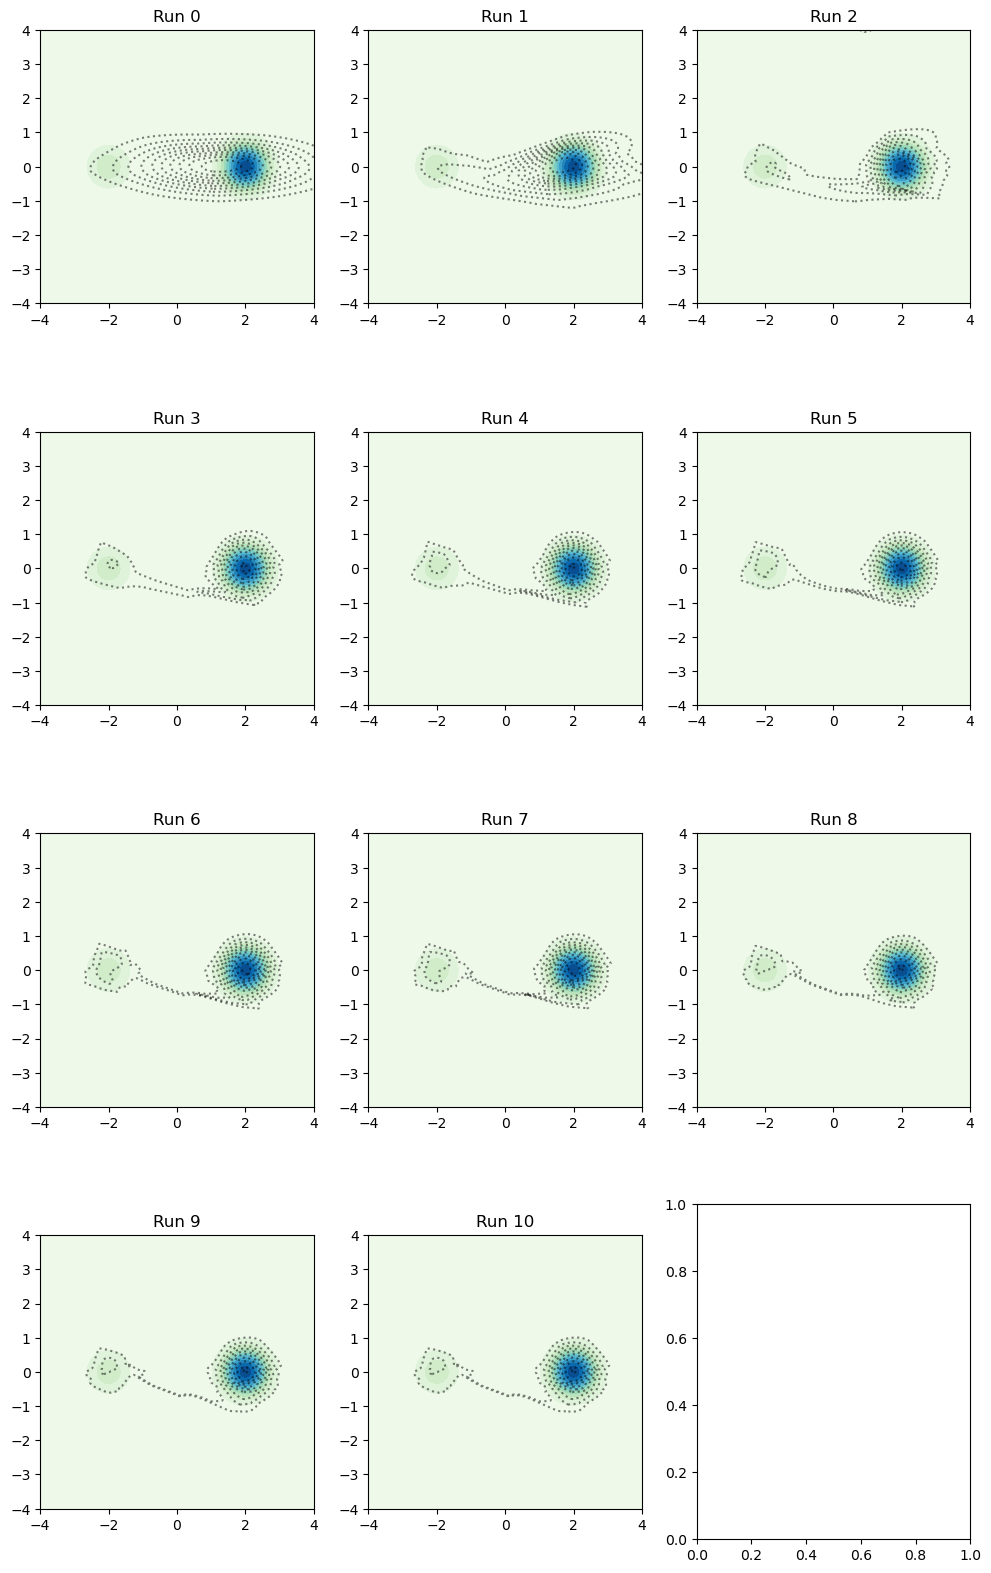

In [15]:
fig, axs = plt.subplots(4, 3, figsize=(12,20))
axs = axs.ravel()
for ax, i in zip(axs, list(range(len(_['dict_flows_training'])))):
    flowlogprob = lambda x: -_['dict_flows_training'][i][0]['model'].nll(x)
    set_plot(ax, n_points=1000, target_log_prob=target.log_prob, prop_log_prob=flowlogprob, lims=lims)
    ax.set_title('Run {}'.format(i))

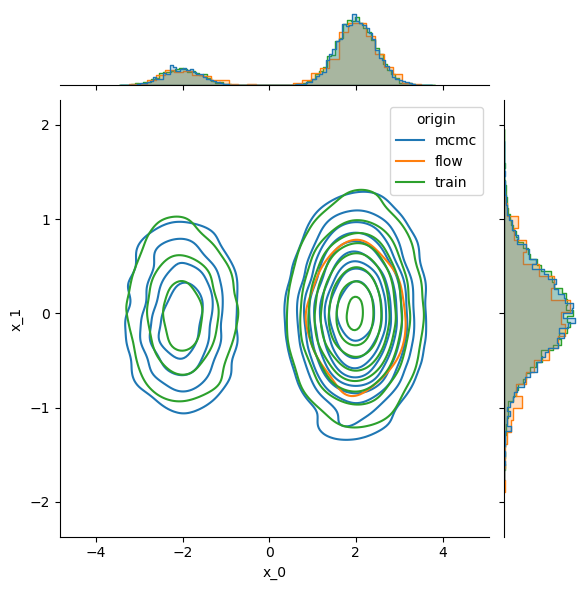

In [16]:
xs = torch.stack(_['xs']).squeeze().reshape(-1, 2)
flow_dic = _['dict_flows_training'][-1][0]
flow_samples = flow_dic['model'].sample(1000) 

import seaborn as sns
import pandas as pd

datas = [
            xs.view(-1,2).detach().numpy(), 
            flow_samples.detach().numpy(),
            train.detach().numpy()
]
labels = ['mcmc', 'flow', 'train']

frames = []
for d, l in zip(datas, labels):
    df = pd.DataFrame(
        {"x_{:d}".format(0): d[:,0], "x_{:d}".format(1): d[:, 1]}
    )
    df["origin"] = l
    frames.append(df)

dfs = pd.concat(frames, ignore_index=True)
g = sns.JointGrid(
    data=dfs, x="x_{:d}".format(0), y="x_{:d}".format(1), hue="origin"
)
g.plot_joint(sns.kdeplot)
g.plot_marginals(sns.histplot, element="step", fill=True, stat='density', common_bins=False, common_norm=False)

## Acceptance while training

In [17]:
from flonacomldft.utils.diagnostics import avg_windows
from flonacomldft.utils.plots import set_plot_iteration

In [18]:
accs = torch.stack(_['accs'])
accs_flatten = accs.reshape(-1, n_chains)

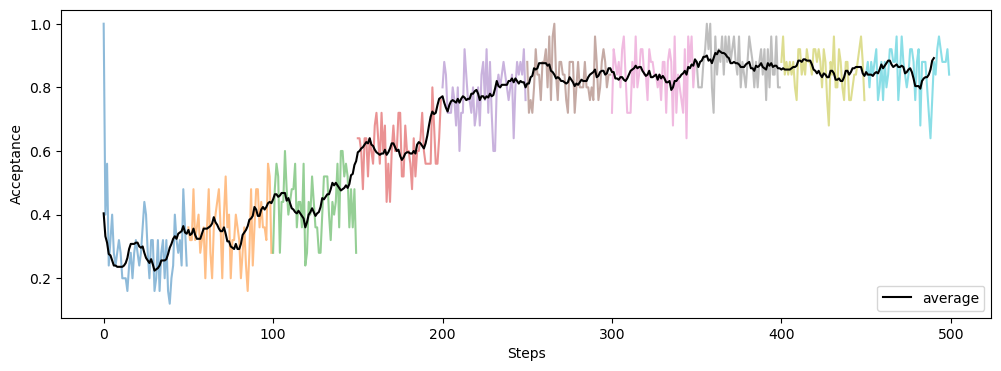

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(12,4) )
i=0
for acc in accs:
    set_plot_iteration(acc.mean(dim=1), avg=False, window_size=10, axis=1, ax=ax, init=i)
    if i > 0:
        i += acc.shape[0]
    else:
        i += acc.shape[0]

window_size = 10
axis = 1

x_avg = np.arange(len(avg_windows(accs_flatten.mean(dim=1), window_size, axis)))
y_avg = avg_windows(accs_flatten.mean(dim=1), window_size, axis)
ax.plot(x_avg, y_avg, color="k", label='average')

ax.set_xlabel('Steps')
ax.set_ylabel('Acceptance')
ax.legend()

## Plotting the losses

In [20]:
dict_flows_training = _['dict_flows_training']
losses_train = torch.cat([torch.tensor(dict_flows_training[i][0]['losses'][0]) for i in range(len(dict_flows_training))])
losses_test = torch.cat([torch.tensor(dict_flows_training[i][0]['losses'][1]) for i in range(len(dict_flows_training))])

In [21]:
y_lines = np.cumsum([len(dict_flows_training[i][0]['losses'][0]) for i in range(len(dict_flows_training))])

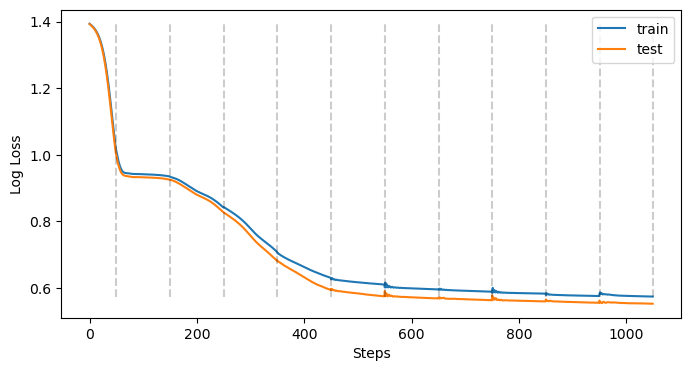

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(8,4) )
set_plot_iteration(torch.log(losses_train), avg=False, window_size=10, axis=0, alpha=1, ax=ax, label='train')
set_plot_iteration(torch.log(losses_test), avg=False, window_size=10, axis=0,alpha=1, ax=ax, label='test')

ax.vlines(y_lines, ymin=torch.log(losses_train.min()), ymax=torch.log(losses_train.max()), color='k', alpha=0.2, linestyle='--')

ax.set_xlabel('Steps')
ax.set_ylabel('Log Loss')
ax.set_label(['train', 'test'])
ax.legend()    